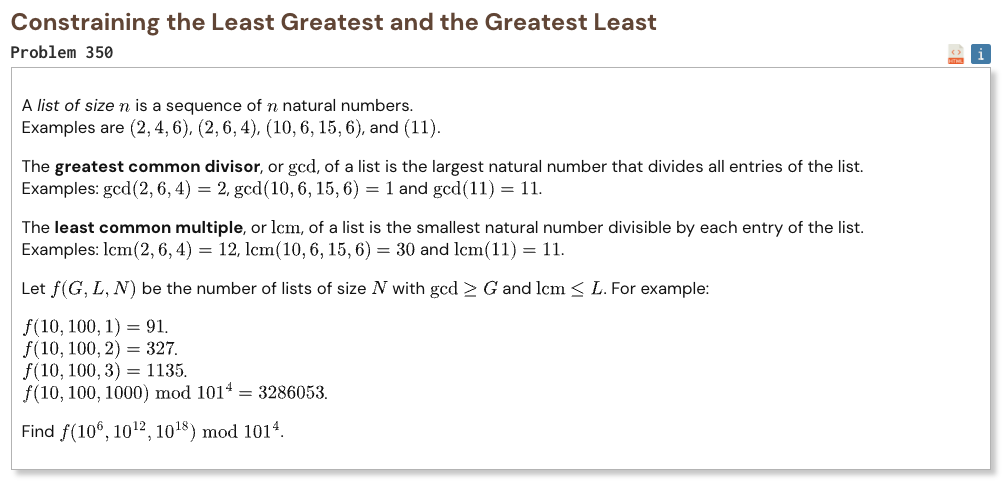

## Initial approach

* fix the gcd first and divide every list element by it
* after division, the new list must have gcd exactly one
* now only the lcm limit changes
* count lists by exact lcm value
* this becomes multiplicative over prime powers
* build prefix sums for all possible reduced lcm values
* group equal floor divisions to sum fast

In [1]:
from array import array

MOD = 101 ** 4

def linear_sieve_spf(limit):
    spf = array("I", [0]) * (limit + 1)
    primes = []

    if limit >= 1:
        spf[1] = 1

    for i in range(2, limit + 1):
        if spf[i] == 0:
            spf[i] = i
            primes.append(i)

        for p in primes:
            value = i * p

            if value > limit or p > spf[i]:
                break

            spf[value] = p

    return spf

def build_prefix(limit, size):
    max_exp = 0
    x = limit

    while x > 1:
        x //= 2
        max_exp += 1

    powers = [pow(i, size, MOD) for i in range(max_exp + 2)]
    contribution = [0] * (max_exp + 1)

    for e in range(1, max_exp + 1):
        contribution[e] = (powers[e + 1] - 2 * powers[e] + powers[e - 1]) % MOD

    spf = linear_sieve_spf(limit)
    exp = bytearray(limit + 1)
    rest = array("I", [0]) * (limit + 1)
    count = array("I", [0]) * (limit + 1)

    rest[1] = 1
    count[1] = 1

    for i in range(2, limit + 1):
        p = spf[i]
        m = i // p

        if spf[m] == p:
            exp[i] = exp[m] + 1
            rest[i] = rest[m]
        else:
            exp[i] = 1
            rest[i] = m

        count[i] = count[rest[i]] * contribution[exp[i]] % MOD

    prefix = array("I", [0]) * (limit + 1)
    total = 0

    for i in range(1, limit + 1):
        total = (total + count[i]) % MOD
        prefix[i] = total

    return prefix

def f(g, l, n):
    reduced_limit = l // g
    prefix = build_prefix(reduced_limit, n)

    total = 0
    d = g

    while d <= l:
        q = l // d
        r = l // q
        total = (total + (r - d + 1) * prefix[q]) % MOD
        d = r + 1

    return total

assert f(10, 100, 1) == 91
assert f(10, 100, 2) == 327
assert f(10, 100, 3) == 1135
assert f(10, 100, 1000) == 3286053

In [2]:
%%time
result = f(10 ** 6, 10 ** 12, 10 ** 18)
print("Result:", result)

Result: 84664213
CPU times: user 495 ms, sys: 9.92 ms, total: 505 ms
Wall time: 514 ms
